In [1]:
# Tratamiento de datos
import pandas as pd
import numpy as np

#Graficos
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

#Procesado y modelado
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import statsmodels as sms
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import jarque_bera




# configuración de matplotlib
plt.rcParams['image.cmap']="bwr"
plt.rcParams['figure.dpi']="100"
plt.rcParams['savefig.bbox']="tight"
style.use('ggplot') or plt.style.use('ggplot')

# configuración de warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
data = pd.read_csv('Advertising.csv')

Saving Advertising.csv to Advertising.csv


# Lectura de datos

In [3]:
#data = pd.read_csv("D:\OneDrive - Benemérita Universidad Autónoma de Puebla\Otoño2024\Analisis de datos\Practicas\Datasets\Advertising.csv")
# Cargar datos
#data = pd.read_csv('/content/drive/MyDrive/ciencicias de datos/modulo 4/Tareas/clase 1 /Advertising.csv')
data.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


# Análisis Exploratorio descriptivo

```
# Tiene formato de código
```



In [4]:
 # Verificando na's

In [5]:
data.describe()


,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
#data = data.drop("newspaper", axis=1)

In [7]:
data.columns

Index(['TV', 'radio', 'newspaper', 'sales'], dtype='object')

<Axes: >

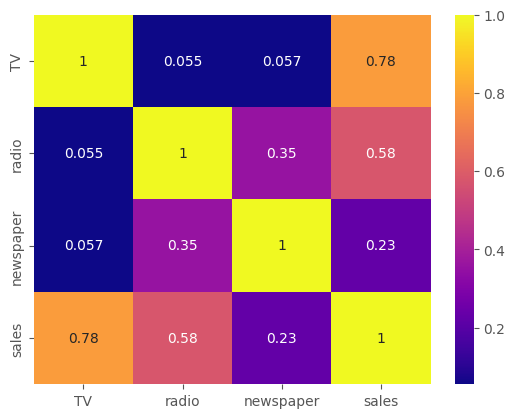

In [8]:
sns.heatmap(data.corr(), annot=True,cmap='plasma')

# Ajsute del modelo múltiple

In [9]:
#X_orig = pd.DataFrame(data=data, columns=['TV','radio'])
X_orig = pd.DataFrame(data=data, columns=['TV','radio','newspaper'])
X_orig.head()

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


In [10]:
y_orig = data['sales']
y_orig.head()

,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_orig, y_orig, random_state=123,train_size = 0.8) #80% para entrenamiento, 20% para prueba
df = pd.concat([X_train,y_train], axis=1)
X_train.shape
X_test.shape
y_train.shape
y_test.shape


(40,)

In [12]:
X_orig.isna().sum()

,0
TV,0
radio,0
newspaper,0


In [13]:
x_train = sm.add_constant(X_train)
modelo = sm.OLS(y_train,x_train).fit()
modelo.summary()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     409.8
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           9.89e-74
Time:                        20:11:50   Log-Likelihood:                -313.24
No. Observations:                 160   AIC:                             634.5
Df Residuals:                     156   BIC:                             646.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9242      0.365      8.018      0.0

## ANOVA

## $$H_0: \beta_1=\beta_2=\beta_3=0 \quad vs \quad H_a:\text{al menos uno} \neq 0 $$

* F-statistic:
* $p_{valor}$=
* Conclusión:



## Pruebas individuales

## $$H_0: \beta_i=0 \quad vs \quad H_a:\beta_i \neq 0 $$

* Inferencia para $\beta_1$: $p_{valor}=0, entonces Se rechaza $H_0$, y afirmamos que
$\beta_1\neq 0$

* Inferencia para $\beta_2$: $p_{valor}=0, entonces Se rechaza $H_0$, y afirmamos que
$\beta_2\neq 0$

* Inferencia para $\beta_3$: $p_{valor}=0, entonces Se rechaza $H_0$, y afirmamos que
$\beta_3 = 0$



## $$ \hat{y}= \beta_0+\beta_1 X_1+ \beta_2 X_2 $$

## Extracción de información del modelo

* APlicar ANOVA
* Analizar las pruebas individuales
* $R^2_{adj}$
* Durbin-Watson:             
* Jarque-Bera (JB):
* Comprobar supuesto de residuales


## Supuestos del modelo

## Normalidad de los errores

In [14]:
resid_val = modelo.resid
fitted_val= modelo.predict()
print(f"Media de los residuales: {modelo.resid.mean()}")
print(f"Desviación estándar de los residuales: {modelo.resid.std()}")

Media de los residuales: 1.1890488593735426e-14
Desviación estándar de los residuales: 1.7193313538135335


In [15]:
stat, p_value, _, _ = jarque_bera(resid_val)

print(f'Estadístico de Jarque-Bera: {stat:.4f}')
print(f'P-valor: {p_value:.4f}')

if p_value > 0.05:
    print("No se rechaza H0: Los residuos parecen normales")
else:
    print("Se rechaza H0: Los residuos NO son normales")

Estadístico de Jarque-Bera: 123.5120
P-valor: 0.0000
Se rechaza H0: Los residuos NO son normales


## Linealidad del modelo

Text(0.5, 1.0, 'Fitted vs Observed')

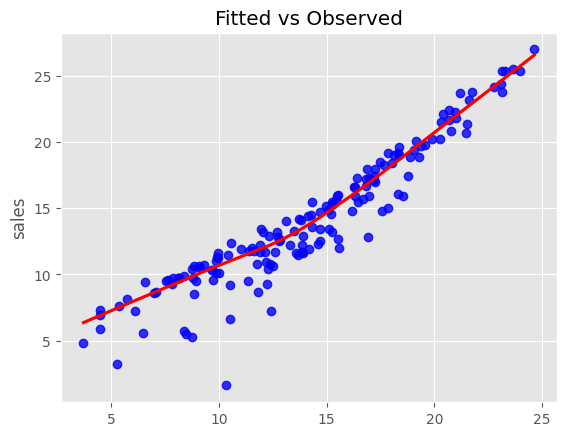

In [16]:
# Linearity in Model

sns.regplot(x=fitted_val,y = y_train, color='blue', lowess=True, line_kws={'color':'red'})
plt.title('Fitted vs Observed')

## Autocorrelación

### Prueba de Durbin-Watson

### Hipótesis:
- $H_0$: No hay autocorrelación en los residuos ($\rho = 0$).
- $H_1$:Existe autocorrelación en los residuos ($\rho \neq 0$).

In [17]:
# Calcular el estadístico de Durbin-Watson


# 2: No hay autocorrelación.
# < 2: Posible autocorrelación positiva.
# > 2: Posible autocorrelación negativa

## Heterocedasticidad

### Hipótesis:
- $H_0$: Los residuos tienen varianza constante (homocedasticidad).
- $H_1$: La varianza de los residuos no es constante (heterocedasticidad).

In [18]:
from statsmodels.stats.diagnostic import het_breuschpagan

# modelo es el resultado de tu regresión
bp = het_breuschpagan(modelo.resid, modelo.model.exog)

# Resultados
print(f"Estadístico LM: {bp[0]}")
print(f"P-valor: {bp[1]}")
print(f"Estadístico F: {bp[2]}")
print(f"P-valor F: {bp[3]}")

# Si el p-valor es < 0.05, se rechaza H0 (existe heterocedasticidad).

Estadístico LM: 5.967316622603374
P-valor: 0.11321121493763223
Estadístico F: 2.0145105413446984
P-valor F: 0.1141528843817307


In [19]:
# Prueba de Breusch-Pagan


# Resultados: estadístico, p-valor, estadístico F y p-valor F
print(f"Estadístico LM: {bp[0]}")
print(f"P-valor: {bp[1]}")
print(f"Estadístico F: {bp[2]}")
print(f"P-valor F: {bp[3]}")

# Si el p-valor es < 0.05, se rechaza H0 (existe heterocedasticidad).

Estadístico LM: 5.967316622603374
P-valor: 0.11321121493763223
Estadístico F: 2.0145105413446984
P-valor F: 0.1141528843817307


Text(0.5, 1.0, 'Fitted vs Residuals')

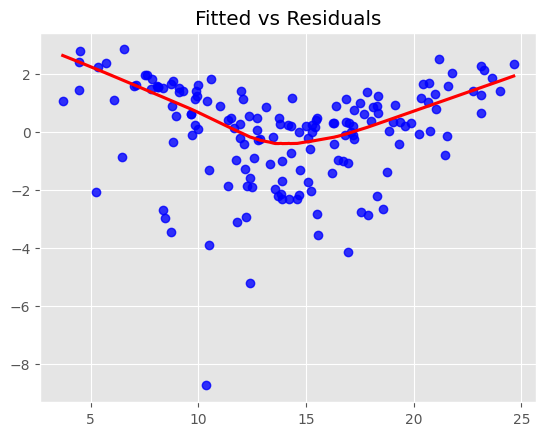

In [20]:

# Homocedasticidad: Igauldad de varianzas
sns.regplot(x=fitted_val,y = resid_val, color='blue', lowess=True, line_kws={'color':'red'})
plt.title('Fitted vs Residuals')

## Outliers

,TV,radio,newspaper
130,0.7,39.6,8.7
5,8.7,48.9,75.0


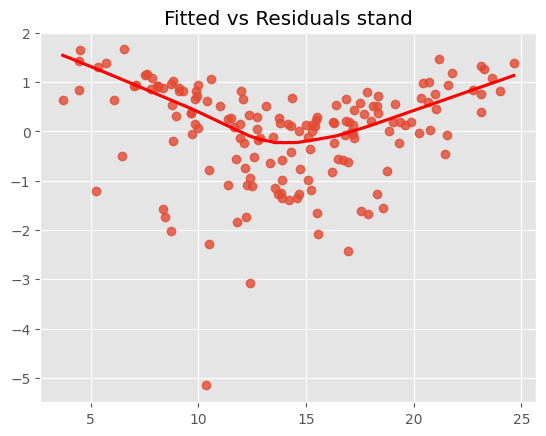

In [21]:
# Es mejor usar los residuales estandarizados
resid_stand= modelo.get_influence().resid_studentized_internal
sns.regplot(x=fitted_val,y = resid_stand, lowess=True, line_kws={'color':'red'})
plt.title('Fitted vs Residuals stand')

# Umbral típico para outliers (|residuo| > 2)
outliers = abs(resid_stand) > 3
# Mostrar las observaciones con outliers
X_train[outliers]

In [22]:
# Obtener la distancia de Cook
infl = modelo.get_influence()
distancia_cook = infl.cooks_distance[0]

# Umbral típico: valores > 4/n (donde n es el número de observaciones)
umbral = 4 / len(X_train)
outliers_cook = distancia_cook > umbral

# Mostrar las observaciones con alta influencia
X_train[outliers_cook]

,TV,radio,newspaper
130,0.7,39.6,8.7
35,290.7,4.1,8.5
5,8.7,48.9,75.0
165,234.5,3.4,84.8
91,28.6,1.5,33.0
25,262.9,3.5,19.5
75,16.9,43.7,89.4
131,265.2,2.9,43.0
2,17.2,45.9,69.3
78,5.4,29.9,9.4


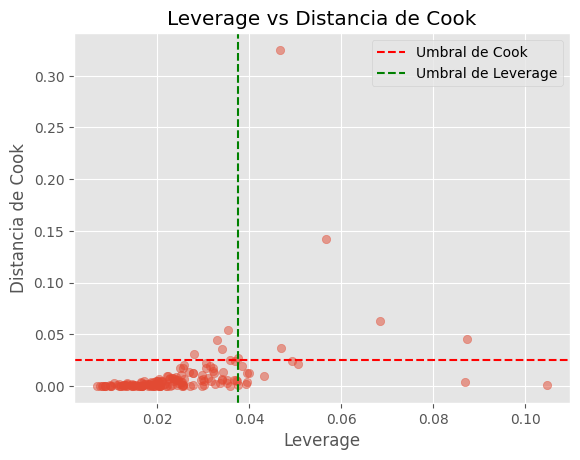

In [23]:
# Leverage vs Distancia de Cook

# Obtener leverage
infl = modelo.get_influence()
leverage = infl.hat_matrix_diag

# Graficar leverage vs distancia de Cook
plt.scatter(leverage, distancia_cook, alpha=0.5)
plt.xlabel("Leverage")
plt.ylabel("Distancia de Cook")
plt.title("Leverage vs Distancia de Cook")

# Umbrales típicos
plt.axhline(y=umbral, color='r', linestyle='--', label="Umbral de Cook")
plt.axvline(x=2*modelo.df_model/len(X_train), color='g', linestyle='--', label="Umbral de Leverage")
plt.legend()
plt.show()

# Puntos con alta distancia de Cook  Son influyentes.
# Puntos con alto leverage  Son potenciales outliers.

## Puntos de Alta influencia

In [24]:
# Obtener la influencia del modelo
influencia = modelo.get_influence()

# Calcular la distancia de Cook
distancia_cook = influencia.cooks_distance[0]

# Definir un umbral típico (4/n)
umbral_cook = 4 / len(X_train)

# Identificar observaciones con alta influencia
outliers_cook = np.where(distancia_cook > umbral_cook)[0]

# Mostrar las observaciones influyentes
X_train.iloc[outliers_cook]

,TV,radio,newspaper
130,0.7,39.6,8.7
35,290.7,4.1,8.5
5,8.7,48.9,75.0
165,234.5,3.4,84.8
91,28.6,1.5,33.0
25,262.9,3.5,19.5
75,16.9,43.7,89.4
131,265.2,2.9,43.0
2,17.2,45.9,69.3
78,5.4,29.9,9.4


valores limite de apalancamiento: 0.05


0.05

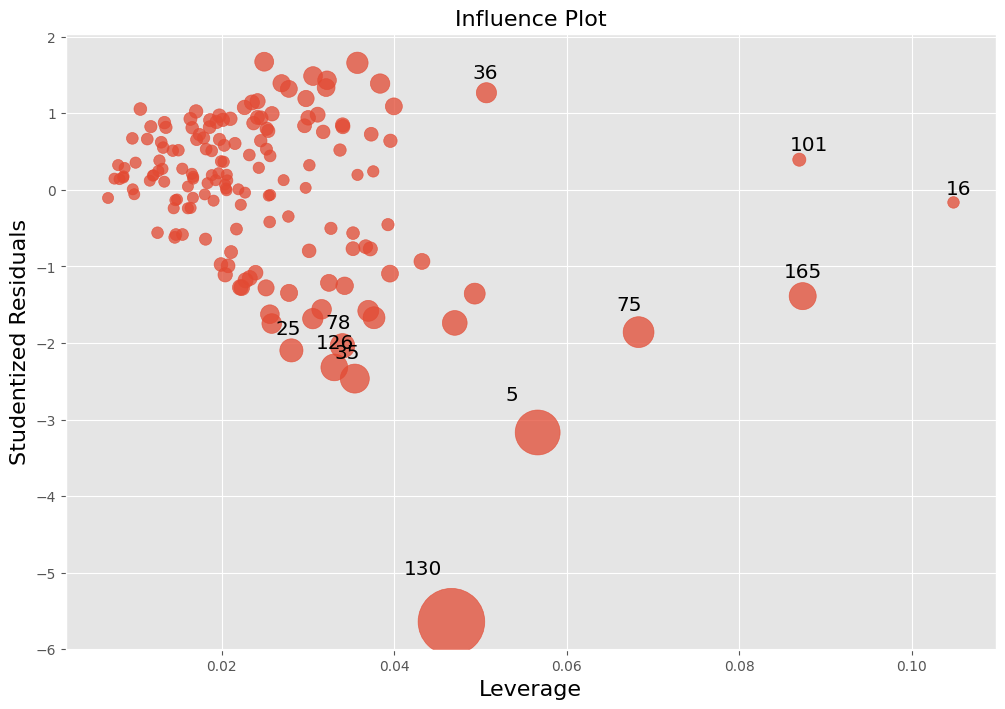

In [25]:
# Leverage points: Apalancamiento

# Influence points: cook distance (Gráfico de influencia)
fig, ax= plt.subplots(figsize=(12,8))
sm.graphics.influence_plot(modelo, alpha= 0.05, ax=ax,criterion="cooks")

# Para determinar los valores límites del apalancamiento, se utiliza la fórmula 2*p/n, donde
#p: el número de coeficientes
#n: el número de observaciones
print("valores limite de apalancamiento:", (2*(X_train.shape[1]+1))/X_train.shape[0])

2*((X_train.shape[1]+1)/X_train.shape[0])

In [26]:
X_train.loc[[130,165,16,101,5,75]]

,TV,radio,newspaper
130,0.7,39.6,8.7
165,234.5,3.4,84.8
16,67.8,36.6,114.0
101,296.4,36.3,100.9
5,8.7,48.9,75.0
75,16.9,43.7,89.4


In [27]:
y_train.loc[[130,165,16,101,5,75]]

,sales
130,1.6
165,11.9
16,12.5
101,23.8
5,7.2
75,8.7


## Colinealidad

### Número de condición


In [28]:
from numpy.linalg import cond

# Calcular número de condición
numero_condicion = cond(X_train)
print(f"Número de condición: {numero_condicion:.2f}")

Número de condición: 12.95


VIF

## VIF
The Variance Inflation Factor is the measure of multicollinearity that exists in the set of variables that are involved in multiple regressions. Generally, the vif value above 10 indicates that there is a high correlation with the other independent variables.

[https://en.wikipedia.org/wiki/Variance_inflation_factor#See_also](https://en.wikipedia.org/wiki/Variance_inflation_factor#See_also)

In [29]:

# Seleccionar solo las variables predictoras del modelo
X = X_train[['TV']]  # Reemplaza con todas las variables predictoras en tu modelo

# Agregar una constante para la regresión
X = sm.add_constant(X)

# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Mostrar resultados
print(vif_data)

  Variable       VIF
0    const  4.094792
1       TV  1.000000


# Conclusión del modelo

## Modelo 2

Ajusta un nuevo modelo que no contenga a la variable newspaper, y compara el desemepeño de los modelos y argumenta cual es el mejor.

In [30]:

influence = modelo.get_influence()

Text(0, 0.5, 'Cooks Distance')

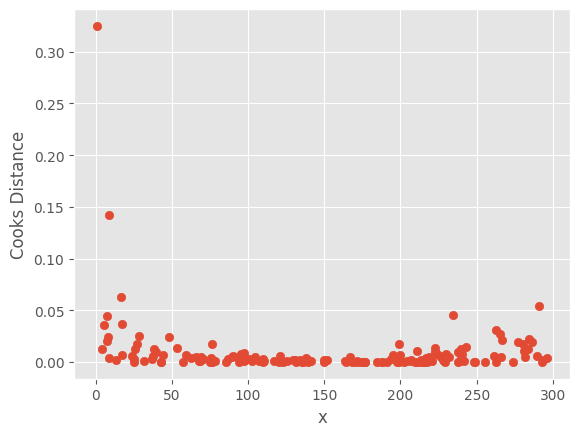

In [31]:

# Distancia de Cook para tv
cooks = influence.cooks_distance

plt.scatter(X_train.TV, cooks[0])   ### cooks[1] (pvalue)
plt.xlabel('x')
plt.ylabel('Cooks Distance')
#plt.show()

Text(0, 0.5, 'Cooks Distance')

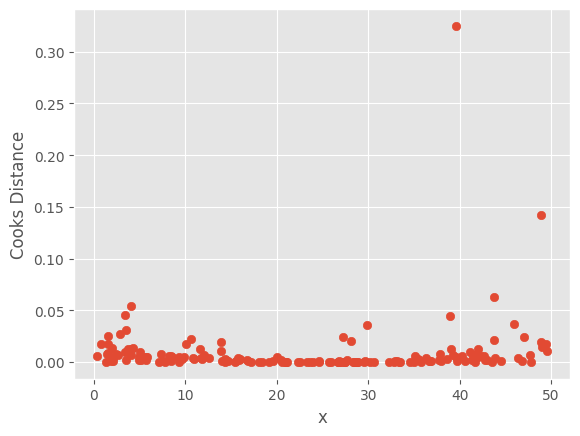

In [32]:
# Distancia de Cook para radio
plt.scatter(X_train.radio, cooks[0])   ### cooks[1] (pvalue)
plt.xlabel('x')
plt.ylabel('Cooks Distance')
#plt.show()

Text(0, 0.5, 'Cooks Distance')

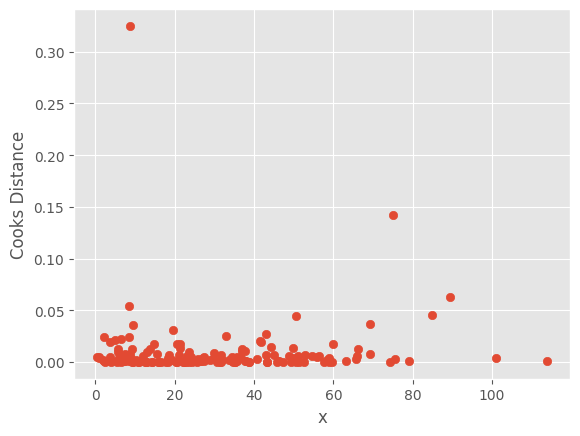

In [33]:
# Distancia de Cook para newspapaer
plt.scatter(X_train.newspaper, cooks[0])   ### cooks[1] (pvalue)
plt.xlabel('x')
plt.ylabel('Cooks Distance')
#plt.show()

In [34]:
# Eliminar las observaciones con leverage alto

k = cooks[0] > 0.050

X_train[k]

y_train[k]

,sales
130,1.6
35,12.8
5,7.2
75,8.7


In [35]:
X2_train = X_train.loc[ k!=1, : ]  ## X[k!=1]

y2_train = y_train[k!=1]

print(X2_train.shape)
print(y2_train.shape)

(156, 3)
(156,)


In [36]:
X2_train.head()

,TV,radio,newspaper
24,62.3,12.6,18.3
150,280.7,13.9,37.0
114,78.2,46.8,34.5
33,265.6,20.0,0.3
23,228.3,16.9,26.2


In [37]:
data2 = data.drop("newspaper", axis=1)

In [38]:
data2.head()

,TV,radio,sales
0,230.1,37.8,22.1
1,44.5,39.3,10.4
2,17.2,45.9,9.3
3,151.5,41.3,18.5
4,180.8,10.8,12.9
